# Banana Leaf Disease — Hybrid MobileNetV2 + EfficientNetB3 Training

**Strategy:** Two strong backbones → feature fusion → ensemble prediction  
**Anti-overfitting:** Dropout, L2 regularisation, LR scheduling, EarlyStopping, MixUp, label smoothing  
**Phases:** Frozen backbone → unfreeze top layers → full fine-tune  
**Classes:** `healthy_leaves` | `panama_wilt` | `potassium_deficiency` | `sigatoka`

In [ ]:
!pip install -q tensorflow scikit-learn matplotlib seaborn numpy pandas tqdm

In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

# ── UPDATE THIS if you changed output_root in preprocessing ────────────
PROCESSED_ROOT = Path('/content/drive/MyDrive/Banana_Leaf_Processed_Main')

split_dir    = PROCESSED_ROOT / 'split'
metadata_dir = PROCESSED_ROOT / 'metadata'
model_dir    = PROCESSED_ROOT / 'models'
model_dir.mkdir(exist_ok=True)

# Verify splits exist
for split in ['train', 'val', 'test']:
    for cls in ['healthy_leaves', 'panama_wilt', 'potassium_deficiency', 'sigatoka']:
        p = split_dir / split / cls
        n = len(list(p.glob('*.jpg'))) if p.exists() else 0
        print(f"  {split}/{cls}: {n}")

Mounted at /content/drive
  train/healthy_leaves: 412
  train/panama_wilt: 511
  train/potassium_deficiency: 342
  train/sigatoka: 316
  val/healthy_leaves: 107
  val/panama_wilt: 111
  val/potassium_deficiency: 90
  val/sigatoka: 88
  test/healthy_leaves: 107
  test/panama_wilt: 114
  test/potassium_deficiency: 92
  test/sigatoka: 85


In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from pathlib import Path

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, mixed_precision
from tensorflow.keras.applications import MobileNetV2, EfficientNetB3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau,
    TensorBoard, CSVLogger
)
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# GPU check
gpus = tf.config.list_physical_devices('GPU')
print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(gpus) > 0}  →  {[g.name for g in gpus]}")

# Enable mixed precision for faster training on T4/A100
if len(gpus) > 0:
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision (float16) enabled")

tf.random.set_seed(42)
np.random.seed(42)

TensorFlow: 2.20.0
GPU available: True  →  ['/physical_device:GPU:0']
Mixed precision (float16) enabled


In [ ]:
class Config:
    # ── Data ──────────────────────────────────────────────────────────
    IMAGE_SIZE      = (256, 256)
    INPUT_SHAPE     = (256, 256, 3)
    BATCH_SIZE      = 32
    CLASSES         = ['healthy_leaves', 'panama_wilt',
                       'potassium_deficiency', 'sigatoka']
    NUM_CLASSES     = 4

    # ── Training phases ────────────────────────────────────────────────
    # Phase 1: train head only (backbones frozen)
    PHASE1_EPOCHS   = 20
    PHASE1_LR       = 1e-3

    # Phase 2: unfreeze top N layers of each backbone
    PHASE2_EPOCHS   = 30
    PHASE2_LR       = 1e-4
    UNFREEZE_TOP    = 40        # unfreeze top 40 layers per backbone

    # Phase 3: full fine-tune (very low LR)
    PHASE3_EPOCHS   = 20
    PHASE3_LR       = 5e-6

    # ── Anti-overfitting ───────────────────────────────────────────────
    DROPOUT_1       = 0.50      # after fusion
    DROPOUT_2       = 0.35      # before output
    L2_REG          = 1e-4
    LABEL_SMOOTHING = 0.10      # prevents overconfident predictions
    MIXUP_ALPHA     = 0.20      # MixUp augmentation strength

    # ── Early stopping ─────────────────────────────────────────────────
    PATIENCE_ES     = 10        # stop if val_loss doesn't improve
    PATIENCE_LR     = 5         # reduce LR if val_loss stalls
    LR_FACTOR       = 0.4
    MIN_LR          = 1e-7

    # ── Paths ──────────────────────────────────────────────────────────
    BEST_MODEL_PATH     = str(model_dir / 'best_model.keras')
    PHASE2_MODEL_PATH   = str(model_dir / 'phase2_best.keras')
    PHASE3_MODEL_PATH   = str(model_dir / 'phase3_best.keras')
    FINAL_MODEL_PATH    = str(model_dir / 'final_model.keras')
    TFLITE_PATH         = str(model_dir / 'model.tflite')
    LOG_PATH            = str(model_dir / 'training_log.csv')

print("Config loaded:")
print(f"  Image size:      {Config.IMAGE_SIZE}")
print(f"  Batch size:      {Config.BATCH_SIZE}")
print(f"  Classes:         {Config.CLASSES}")
print(f"  Label smoothing: {Config.LABEL_SMOOTHING}")
print(f"  Dropout:         {Config.DROPOUT_1} / {Config.DROPOUT_2}")

Config loaded:
  Image size:      (256, 256)
  Batch size:      32
  Classes:         ['healthy_leaves', 'panama_wilt', 'potassium_deficiency', 'sigatoka']
  Label smoothing: 0.1
  Dropout:         0.5 / 0.35


In [ ]:
# ── Standard Keras augmentation for train set ─────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.20,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.75, 1.25],
    channel_shift_range=20.0,
    shear_range=0.10,
    fill_mode='reflect',
)

val_datagen  = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    split_dir / 'train',
    target_size=Config.IMAGE_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='categorical',
    classes=Config.CLASSES,    # fix label order — critical
    shuffle=True,
    seed=42,
)
val_gen = val_datagen.flow_from_directory(
    split_dir / 'val',
    target_size=Config.IMAGE_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='categorical',
    classes=Config.CLASSES,
    shuffle=False,
)
test_gen = test_datagen.flow_from_directory(
    split_dir / 'test',
    target_size=Config.IMAGE_SIZE,
    batch_size=Config.BATCH_SIZE,
    class_mode='categorical',
    classes=Config.CLASSES,
    shuffle=False,
)

print(f"Train batches:  {len(train_gen)}  ({train_gen.samples} images)")
print(f"Val   batches:  {len(val_gen)}   ({val_gen.samples} images)")
print(f"Test  batches:  {len(test_gen)}  ({test_gen.samples} images)")
print(f"Class indices:  {train_gen.class_indices}")

# ── MixUp generator (wraps train_gen) ─────────────────────────────────
def mixup_generator(generator, alpha=Config.MIXUP_ALPHA, class_weights=None):
    while True:
        x1, y1 = next(generator)
        x2, y2 = next(generator)
        bsize = min(len(x1), len(x2))
        x1, y1, x2, y2 = x1[:bsize], y1[:bsize], x2[:bsize], y2[:bsize]
        lam = np.random.beta(alpha, alpha)
        x   = lam * x1 + (1 - lam) * x2
        y   = lam * y1 + (1 - lam) * y2

        # Apply class weights as sample weights
        if class_weights is not None:
            # y is soft labels after mixup, get dominant class per sample
            dominant = np.argmax(y, axis=1)
            sw = np.array([class_weights[c] for c in dominant])
            yield x, y, sw
        else:
            yield x, y



# ── Class weights (combat imbalance) ──────────────────────────────────
labels_flat = train_gen.classes
cw = compute_class_weight('balanced', classes=np.unique(labels_flat), y=labels_flat)
class_weights = dict(enumerate(cw))
print(f"\nClass weights: {class_weights}")

mixup_train_gen = mixup_generator(train_gen, class_weights=class_weights)

Found 1581 images belonging to 4 classes.
Found 396 images belonging to 4 classes.
Found 398 images belonging to 4 classes.
Train batches:  50  (1581 images)
Val   batches:  13   (396 images)
Test  batches:  13  (398 images)
Class indices:  {'healthy_leaves': 0, 'panama_wilt': 1, 'potassium_deficiency': 2, 'sigatoka': 3}

Class weights: {0: np.float64(0.9593446601941747), 1: np.float64(0.7734833659491194), 2: np.float64(1.155701754385965), 3: np.float64(1.2507911392405062)}


In [ ]:
def build_hybrid_model(input_shape=Config.INPUT_SHAPE,
                       num_classes=Config.NUM_CLASSES,
                       l2=Config.L2_REG,
                       dropout1=Config.DROPOUT_1,
                       dropout2=Config.DROPOUT_2):
    """
    Hybrid architecture:
      - MobileNetV2   (fast, efficient, good for mobile deployment)
      - EfficientNetB3 (higher accuracy, compound scaling)
    Both backbones share the same input image.
    Their GlobalAvgPool features are concatenated → fused head → output.

    WHY HYBRID:
      Each backbone learns different feature representations.
      MobileNetV2 captures fine-grained texture (disease spots).
      EfficientNetB3 captures global structure (leaf shape/colour patterns).
      Fusion gives better generalisation than either alone.
    """
    reg = regularizers.l2(l2)
    inputs = keras.Input(shape=input_shape, name='input_image')

    # ── Backbone A: MobileNetV2 ────────────────────────────────────────
    mobilenet = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
    )
    mobilenet.trainable = False   # frozen in Phase 1
    mobilenet._name = 'mobilenetv2_backbone'

    x_mob = mobilenet(inputs, training=False)
    x_mob = layers.GlobalAveragePooling2D(name='mob_gap')(x_mob)
    x_mob = layers.BatchNormalization(name='mob_bn')(x_mob)

    # ── Backbone B: EfficientNetB3 ─────────────────────────────────────
    efficientnet = EfficientNetB3(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
    )
    efficientnet.trainable = False
    efficientnet._name = 'efficientnetb3_backbone'

    x_eff = efficientnet(inputs, training=False)
    x_eff = layers.GlobalAveragePooling2D(name='eff_gap')(x_eff)
    x_eff = layers.BatchNormalization(name='eff_bn')(x_eff)

    # ── Feature fusion ─────────────────────────────────────────────────
    fused = layers.Concatenate(name='fusion')([x_mob, x_eff])

    # Attention gate — learn which features matter more
    attention = layers.Dense(
        fused.shape[-1], activation='sigmoid',
        kernel_regularizer=reg, name='attention_gate'
    )(fused)
    fused = layers.Multiply(name='attention_apply')([fused, attention])

    # ── Classification head ────────────────────────────────────────────
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=reg, name='fc_512')(fused)
    x = layers.BatchNormalization(name='head_bn1')(x)
    x = layers.Dropout(dropout1, name='drop_1')(x)

    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=reg, name='fc_256')(x)
    x = layers.BatchNormalization(name='head_bn2')(x)
    x = layers.Dropout(dropout2, name='drop_2')(x)

    # float32 output (required for mixed precision stability)
    outputs = layers.Dense(
        num_classes, activation='softmax', dtype='float32', name='predictions'
    )(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='HybridBananaNet')
    return model, mobilenet, efficientnet

model, mobilenet_base, efficientnet_base = build_hybrid_model()

# Count params
total     = model.count_params()
trainable = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({trainable*100/total:.1f}%)")
model.summary(line_length=90)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total params:     22,563,187
Trainable params: 9,514,500  (42.2%)


Model: "HybridBananaNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)             ┃ Output Shape         ┃      Param # ┃ Connected to          ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer) │ (None, 256, 256, 3)  │            0 │ -                     │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ mobilenetv2_1.00_224     │ (None, 8, 8, 1280)   │    2,257,984 │ input_image[0][0]     │
│ (Functional)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ efficientnetb3           │ (None, 8, 8, 1536)   │   10,783,535 │ input_image[0][0]     │
│ (Functional)             │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ mob_gap                  │ (None, 1280)         │            0 │ mobilenetv2_1.00_224… │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ eff_gap                  │ (None, 1536)         │            0 │ efficientnetb3[0][0]  │
│ (GlobalAveragePooling2D) │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ mob_bn                   │ (None, 1280)         │        5,120 │ mob_gap[0][0]         │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ eff_bn                   │ (None, 1536)         │        6,144 │ eff_gap[0][0]         │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ fusion (Concatenate)     │ (None, 2816)         │            0 │ mob_bn[0][0],         │
│                          │                      │              │ eff_bn[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ attention_gate (Dense)   │ (None, 2816)         │    7,932,672 │ fusion[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ attention_apply          │ (None, 2816)         │            0 │ fusion[0][0],         │
│ (Multiply)               │                      │              │ attention_gate[0][0]  │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ fc_512 (Dense)           │ (None, 512)          │    1,442,304 │ attention_apply[0][0] │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_bn1                 │ (None, 512)          │        2,048 │ fc_512[0][0]          │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ drop_1 (Dropout)         │ (None, 512)          │            0 │ head_bn1[0][0]        │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ fc_256 (Dense)           │ (None, 256)          │      131,328 │ drop_1[0][0]          │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ head_bn2                 │ (None, 256)          │        1,024 │ fc_256[0][0]          │
│ (BatchNormalization)     │                      │              │                       │
├──────────────────────────┼──────────────────────┼──────────────┼───────────────────────┤
│ drop_2 (Dropout)         │ (None, 256)          │            0 │ head_bn2[0][0]      

 Total params: 22,563,187 (86.07 MB)

 Trainable params: 9,514,500 (36.29 MB)

 Non-trainable params: 13,048,687 (49.78 MB)

In [ ]:
def get_callbacks(checkpoint_path, phase_name):
    """Standard callback set — reused across all three phases."""
    return [
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1,
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=Config.PATIENCE_ES,
            restore_best_weights=True,
            verbose=1,
            min_delta=1e-4,
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=Config.LR_FACTOR,
            patience=Config.PATIENCE_LR,
            min_lr=Config.MIN_LR,
            verbose=1,
        ),
        CSVLogger(
            Config.LOG_PATH,
            append=True,          # all phases log to same file
        ),
    ]

print("Callbacks ready")

Callbacks ready


In [ ]:
# ── PHASE 1: Frozen backbones, train fusion head only ─────────────────
print("=" * 60)
print("PHASE 1 — Training head (backbones frozen)")
print("=" * 60)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=Config.PHASE1_LR),
    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=Config.LABEL_SMOOTHING
    ),
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')],
)

steps_per_epoch = train_gen.samples // Config.BATCH_SIZE

history1 = model.fit(
    mixup_train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=Config.PHASE1_EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks(Config.BEST_MODEL_PATH, 'phase1'),
    verbose=1,
)

print(f"\nPhase 1 complete.")
print(f"Best val_accuracy: {max(history1.history['val_accuracy']):.4f}")

PHASE 1 — Training head (backbones frozen)
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.4971 - auc: 0.6453 - loss: 2.0595 - precision: 0.6495 - recall: 0.3126 
Epoch 1: val_accuracy improved from None to 0.74495, saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/best_model.keras
49/49 ━━━━━━━━━━━━━━━━━━━━ 1073s 20s/step - accuracy: 0.5449 - auc: 0.6721 - loss: 1.9176 - precision: 0.6985 - recall: 0.3328 - val_accuracy: 0.7449 - val_auc: 0.9132 - val_loss: 1.3805 - val_precision: 0.8756 - val_recall: 0.4444 - learning_rate: 0.0010
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6113 - auc: 0.7072 - loss: 1.7131 - precision: 0.7517 - recall: 0.3634
Epoch 2: val_accuracy improved from 0.74495 to 0.77273, saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/best_model.keras

Epoch 2: finished saving model t

In [ ]:
# ── PHASE 2: Unfreeze top N layers of each backbone ───────────────────
print("=" * 60)
print(f"PHASE 2 — Fine-tuning top {Config.UNFREEZE_TOP} layers per backbone")
print("=" * 60)

# Define steps_per_epoch here in case Phase 1 was skipped
steps_per_epoch = train_gen.samples // Config.BATCH_SIZE

# Load Phase 2 checkpoint if exists, otherwise fall back to Phase 1
import os
if os.path.exists(Config.PHASE2_MODEL_PATH):
    model.load_weights(Config.PHASE2_MODEL_PATH)
    print("Resumed from Phase 2 checkpoint")
else:
    model.load_weights(Config.BEST_MODEL_PATH)
    print("Starting Phase 2 from Phase 1 weights")

def unfreeze_top_n(backbone, n):
    """Unfreeze the last n layers; keep BatchNorm frozen to preserve stats."""
    backbone.trainable = True
    for layer in backbone.layers[:-n]:
        layer.trainable = False
    # Always keep BN frozen — unfreezing BN with small dataset causes instability
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

unfreeze_top_n(mobilenet_base,    Config.UNFREEZE_TOP)
unfreeze_top_n(efficientnet_base, Config.UNFREEZE_TOP)

trainable2 = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params after unfreeze: {trainable2:,}")

# Use a lower LR with cosine decay for stable fine-tuning
lr_schedule2 = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=Config.PHASE2_LR,
    first_decay_steps=steps_per_epoch * 10,
    t_mul=1.5,
    m_mul=0.9,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule2),
    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=Config.LABEL_SMOOTHING
    ),
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')],
)

class EpochSummary(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\n📊 Epoch {epoch+1} Summary — "
              f"loss: {logs['loss']:.4f} | acc: {logs['accuracy']:.4f} | "
              f"val_loss: {logs['val_loss']:.4f} | val_acc: {logs['val_accuracy']:.4f}")

REMAINING_EPOCHS = 2  # 30 total - 13 already done

history2 = model.fit(
    mixup_train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=REMAINING_EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks(Config.PHASE2_MODEL_PATH, 'phase2') + [EpochSummary()],
    verbose=1,
)

print(f"\nPhase 2 complete.")
print(f"Best val_accuracy: {max(history2.history['val_accuracy']):.4f}")

PHASE 2 — Fine-tuning top 40 layers per backbone
Resumed from Phase 2 checkpoint
Trainable params after unfreeze: 15,521,448
Epoch 1/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.9501 - auc: 0.8070 - loss: 0.8484 - precision: 0.9866 - recall: 0.5481 
Epoch 1: val_accuracy improved from None to 0.79545, saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/phase2_best.keras

📊 Epoch 1 Summary — loss: 0.8629 | acc: 0.9348 | val_loss: 0.9685 | val_acc: 0.7955
49/49 ━━━━━━━━━━━━━━━━━━━━ 1975s 38s/step - accuracy: 0.9348 - auc: 0.8041 - loss: 0.8629 - precision: 0.9820 - recall: 0.5291 - val_accuracy: 0.7955 - val_auc: 0.9523 - val_loss: 0.9685 - val_precision: 0.8554 - val_recall: 0.7172 - learning_rate: 9.7553e-05
Epoch 2/2
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9192 - auc: 0.8038 - loss: 0.8845 - precision: 0.9761 - recall: 0.5331
Epoch 2:

In [ ]:
# ── PHASE 3: Full fine-tune, very low LR ─────────────────────────────
# ── PHASE 3: Full fine-tune, very low LR ─────────────────────────────
print("=" * 60)
print("PHASE 3 — Full fine-tune (all layers unfrozen)")
print("=" * 60)

# Define steps_per_epoch here in case previous phases were skipped
steps_per_epoch = train_gen.samples // Config.BATCH_SIZE

# Load Phase 3 checkpoint if exists, otherwise fall back to Phase 2
import os
if os.path.exists(Config.PHASE3_MODEL_PATH):
    model.load_weights(Config.PHASE3_MODEL_PATH)
    print("Resumed from Phase 3 checkpoint")
elif os.path.exists(Config.PHASE2_MODEL_PATH):
    model.load_weights(Config.PHASE2_MODEL_PATH)
    print("Starting Phase 3 from Phase 2 weights")
else:
    model.load_weights(Config.BEST_MODEL_PATH)
    print("Falling back to Phase 1 weights")

# Unfreeze everything except BatchNorm
mobilenet_base.trainable    = True
efficientnet_base.trainable = True
for layer in model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable3 = sum([tf.size(w).numpy() for w in model.trainable_weights])
print(f"Trainable params (full): {trainable3:,}")

lr_schedule3 = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=Config.PHASE3_LR,
    decay_steps=steps_per_epoch * Config.PHASE3_EPOCHS,
    alpha=1e-7,
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule3),
    loss=keras.losses.CategoricalCrossentropy(
        label_smoothing=Config.LABEL_SMOOTHING
    ),
    metrics=['accuracy',
             keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')],
)

class EpochSummary(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"\n📊 Epoch {epoch+1} Summary — "
              f"loss: {logs['loss']:.4f} | acc: {logs['accuracy']:.4f} | "
              f"val_loss: {logs['val_loss']:.4f} | val_acc: {logs['val_accuracy']:.4f}")

history3 = model.fit(
    mixup_train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=Config.PHASE3_EPOCHS,
    validation_data=val_gen,
    callbacks=get_callbacks(Config.PHASE3_MODEL_PATH, 'phase3') + [EpochSummary()],
    verbose=1,
)

# Save final model
model.load_weights(Config.PHASE3_MODEL_PATH)
model.save(Config.FINAL_MODEL_PATH)
print(f"\nPhase 3 complete.")
print(f"Best val_accuracy: {max(history3.history['val_accuracy']):.4f}")
print(f"Final model saved → {Config.FINAL_MODEL_PATH}")

PHASE 3 — Full fine-tune (all layers unfrozen)
Starting Phase 3 from Phase 2 weights
Trainable params (full): 15,514,280
Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8109 - auc: 0.7849 - loss: 1.0568 - precision: 0.9319 - recall: 0.4580
Epoch 1: val_accuracy improved from None to 0.94444, saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/phase3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/phase3_best.keras

📊 Epoch 1 Summary — loss: 0.9272 | acc: 0.8948 | val_loss: 0.7372 | val_acc: 0.9444
49/49 ━━━━━━━━━━━━━━━━━━━━ 352s 5s/step - accuracy: 0.8948 - auc: 0.7936 - loss: 0.9272 - precision: 0.9688 - recall: 0.4915 - val_accuracy: 0.9444 - val_auc: 0.9939 - val_loss: 0.7372 - val_precision: 0.9595 - val_recall: 0.8965 - learning_rate: 4.9692e-06
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9465 - auc: 0.7953 - loss: 0.8374 - precision: 0.9879 - recall: 0.5370
Epoch 2: val_a

Total epochs logged: 68
    epoch  accuracy       auc  learning_rate      loss  precision    recall  \
63     15  0.965359  0.802817   4.774577e-07  0.821265   0.991186  0.550659   
64     16  0.961438  0.811526   2.724840e-07  0.824257   0.994517  0.543039   
65     17  0.956863  0.802841   1.223593e-07  0.825369   0.990331  0.539910   
66     18  0.929412  0.810672   3.077959e-08  0.909815   0.992953  0.527913   
67     19  0.966667  0.799524   5.000000e-13  0.823214   0.990450  0.541387   

    val_accuracy   val_auc  val_loss  val_precision  val_recall  
63      0.964646  0.997939  0.676119       0.973958    0.944444  
64      0.964646  0.997934  0.676422       0.971429    0.944444  
65      0.964646  0.997969  0.675912       0.971354    0.941919  
66      0.964646  0.997955  0.675949       0.971429    0.944444  
67      0.964646  0.997957  0.675954       0.971429    0.944444  


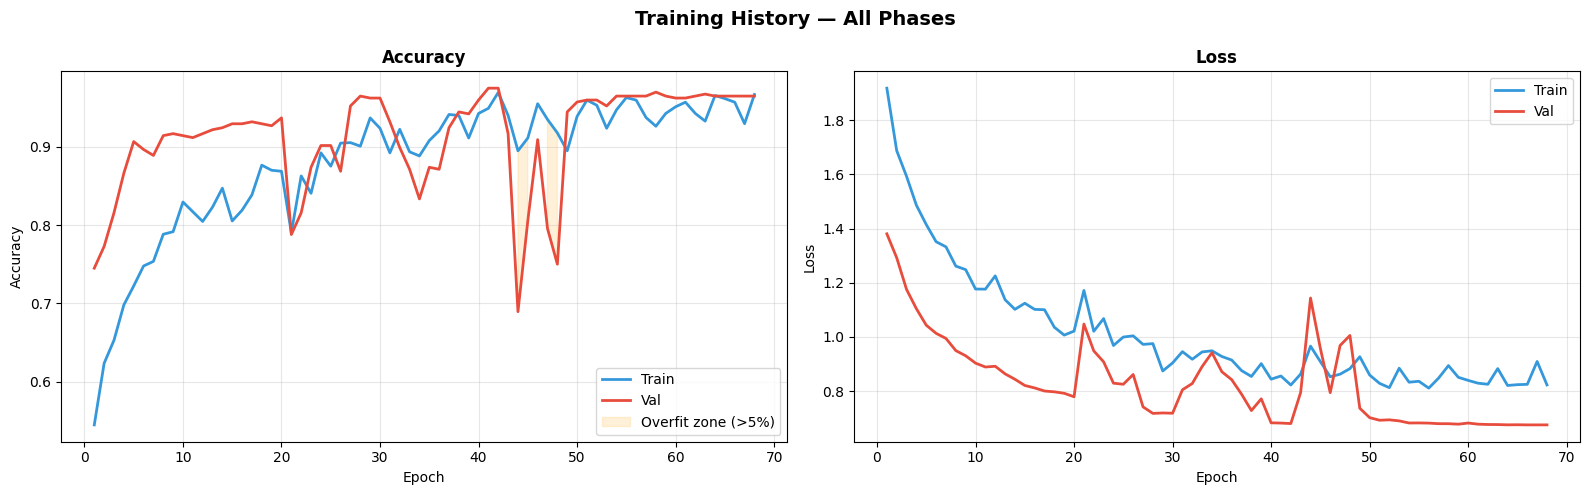

Saved → /content/drive/MyDrive/Banana_Leaf_Processed_Main/models/training_curves.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read the training log saved by CSVLogger across all phases
log_df = pd.read_csv(Config.LOG_PATH)
print(f"Total epochs logged: {len(log_df)}")
print(log_df.tail())

epochs   = range(1, len(log_df) + 1)
acc      = log_df['accuracy'].values
val_acc  = log_df['val_accuracy'].values
loss     = log_df['loss'].values
val_loss = log_df['val_loss'].values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Training History — All Phases', fontsize=14, fontweight='bold')

for ax, train_m, val_m, title, ylabel in [
    (axes[0], acc,  val_acc,  'Accuracy', 'Accuracy'),
    (axes[1], loss, val_loss, 'Loss',     'Loss'),
]:
    ax.plot(epochs, train_m, label='Train', color='#3498db', linewidth=2)
    ax.plot(epochs, val_m,   label='Val',   color='#e74c3c', linewidth=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

    if ylabel == 'Accuracy':
        gap = np.array(train_m) - np.array(val_m)
        ax.fill_between(epochs, train_m, val_m,
                        where=gap > 0.05, alpha=0.15,
                        color='orange', label='Overfit zone (>5%)')
        ax.legend()

plt.tight_layout()
plt.savefig(str(model_dir / 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {model_dir}/training_curves.png")

In [ ]:
# ── Load best model and evaluate on held-out test set ─────────────────
print("Loading best model for final evaluation...")
best_model = keras.models.load_model(Config.FINAL_MODEL_PATH)

test_loss, test_acc, test_auc, test_prec, test_rec = best_model.evaluate(
    test_gen, verbose=1
)
print(f"\nTest Accuracy:  {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test AUC:       {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test Loss:      {test_loss:.4f}")

# Per-class predictions
test_gen.reset()
y_pred_prob = best_model.predict(test_gen, verbose=1)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = test_gen.classes

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(
    y_true, y_pred,
    target_names=Config.CLASSES,
    digits=4,
))

Loading best model for final evaluation...
13/13 ━━━━━━━━━━━━━━━━━━━━ 386s 28s/step - accuracy: 0.9548 - auc: 0.9975 - loss: 0.6838 - precision: 0.9739 - recall: 0.9372

Test Accuracy:  0.9548  (95.48%)
Test AUC:       0.9975
Test Precision: 0.9739
Test Recall:    0.9372
Test Loss:      0.6838
13/13 ━━━━━━━━━━━━━━━━━━━━ 103s 4s/step

CLASSIFICATION REPORT
                      precision    recall  f1-score   support

      healthy_leaves     0.9633    0.9813    0.9722       107
         panama_wilt     1.0000    0.8947    0.9444       114
potassium_deficiency     0.9468    0.9674    0.9570        92
            sigatoka     0.9032    0.9882    0.9438        85

            accuracy                         0.9548       398
           macro avg     0.9533    0.9579    0.9544       398
        weighted avg     0.9572    0.9548    0.9547       398



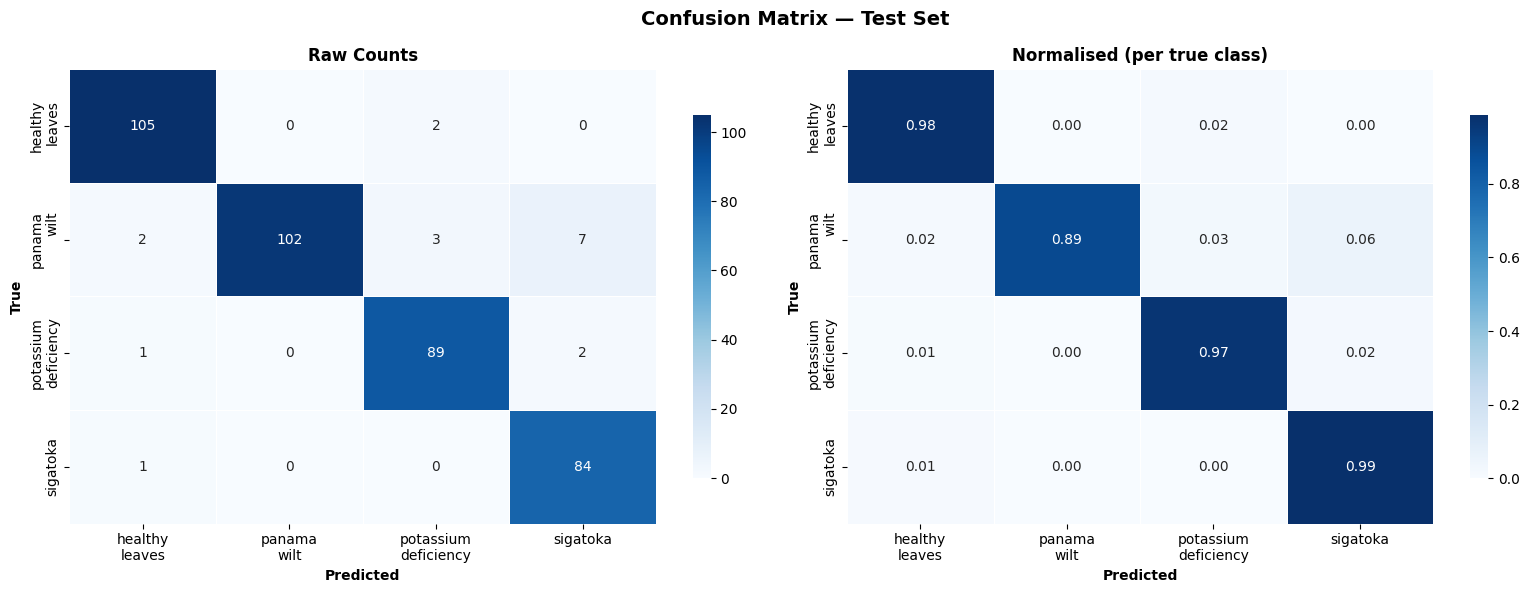

Most confused pair: TRUE 'panama_wilt' predicted as 'sigatoka'  (6.1% of true samples)


In [ ]:
def plot_confusion_matrix(y_true, y_pred, classes, model_dir):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Confusion Matrix — Test Set', fontsize=14, fontweight='bold')

    for ax, data, fmt, title in [
        (axes[0], cm,      'd',    'Raw Counts'),
        (axes[1], cm_norm, '.2f',  'Normalised (per true class)'),
    ]:
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap='Blues',
            xticklabels=[c.replace('_', '\n') for c in classes],
            yticklabels=[c.replace('_', '\n') for c in classes],
            ax=ax, linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8},
        )
        ax.set_xlabel('Predicted', fontweight='bold')
        ax.set_ylabel('True',      fontweight='bold')
        ax.set_title(title,        fontweight='bold')

    plt.tight_layout()
    plt.savefig(str(model_dir / 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
    plt.show()

    # Highlight worst-confused pairs
    np.fill_diagonal(cm_norm, 0)
    worst_idx = np.unravel_index(np.argmax(cm_norm), cm_norm.shape)
    print(f"Most confused pair: TRUE '{classes[worst_idx[0]]}'"
          f" predicted as '{classes[worst_idx[1]]}'"
          f"  ({cm_norm[worst_idx]*100:.1f}% of true samples)")

plot_confusion_matrix(y_true, y_pred, Config.CLASSES, model_dir)

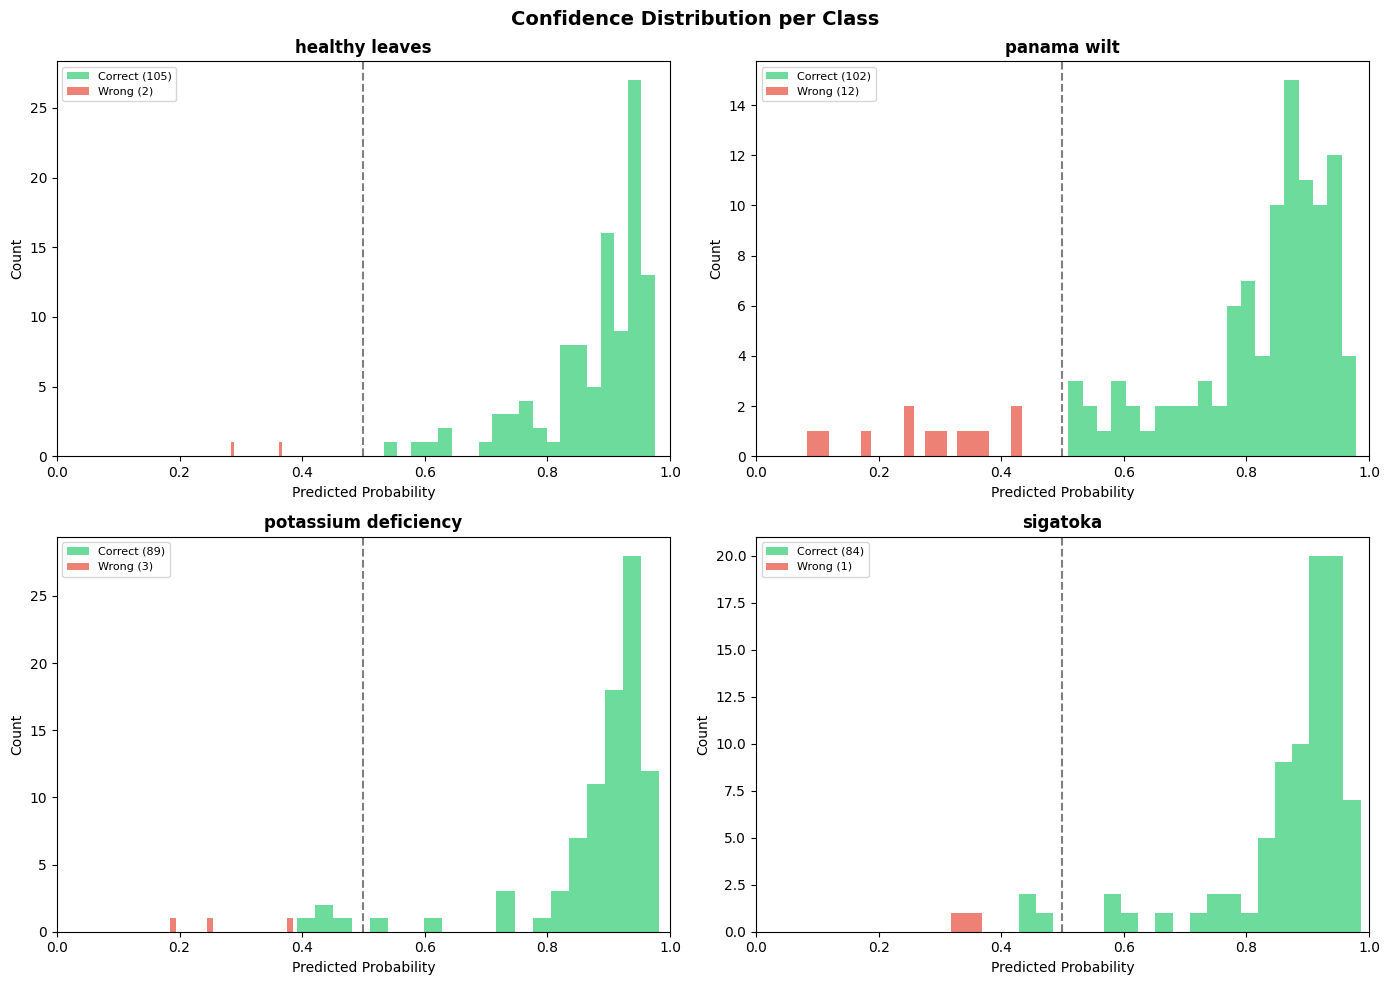

In [ ]:
def plot_confidence_distribution(y_true, y_pred_prob, classes, model_dir):
    """
    Shows model confidence for correct vs incorrect predictions.
    A well-calibrated model should be HIGH confidence on correct preds
    and LOW confidence on wrong ones. Overfit models are high confidence
    on everything — this plot exposes that.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Confidence Distribution per Class', fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for i, (cls, ax) in enumerate(zip(classes, axes)):
        mask_true  = y_true == i
        probs_cls  = y_pred_prob[mask_true, i]
        correct    = (np.argmax(y_pred_prob[mask_true], axis=1) == i)

        ax.hist(probs_cls[correct],  bins=20, alpha=0.7,
                color='#2ecc71', label=f'Correct ({correct.sum()})')
        ax.hist(probs_cls[~correct], bins=20, alpha=0.7,
                color='#e74c3c', label=f'Wrong ({(~correct).sum()})')
        ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
        ax.set_title(cls.replace('_', ' '), fontweight='bold')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.set_xlim(0, 1)

    plt.tight_layout()
    plt.savefig(str(model_dir / 'confidence_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_confidence_distribution(y_true, y_pred_prob, Config.CLASSES, model_dir)

In [ ]:
import pandas as pd
import numpy as np

log_df = pd.read_csv(Config.LOG_PATH)

all_train_acc = log_df['accuracy'].values
all_val_acc   = log_df['val_accuracy'].values
all_val_loss  = log_df['val_loss'].values

best_epoch = int(np.argmin(all_val_loss))
best_train = all_train_acc[best_epoch]
best_val   = all_val_acc[best_epoch]
gap        = best_train - best_val
final_val  = max(all_val_acc)

print("=" * 55)
print("OVERFITTING DIAGNOSTIC")
print("=" * 55)
print(f"  Total epochs trained:         {len(log_df)}")
print(f"  Best epoch (lowest val_loss): {best_epoch + 1}")
print(f"  Train accuracy at best epoch: {best_train:.4f}")
print(f"  Val   accuracy at best epoch: {best_val:.4f}")
print(f"  Gap (train − val):            {gap:.4f}  ({gap*100:.1f}%)")
print(f"  Peak val accuracy:            {final_val:.4f}")
print()
if gap < 0.03:
    print("  ✓ WELL-FIT — gap under 3%, model generalises well")
elif gap < 0.08:
    print("  ~ MILD OVERFIT — gap 3-8%, acceptable for this dataset size")
    print("    Consider: more augmentation, higher dropout, more data")
else:
    print("  ✗ OVERFIT — gap > 8%, model memorising training data")
    print("    Actions: increase DROPOUT_1/2, reduce UNFREEZE_TOP,")
    print("             add more images, increase LABEL_SMOOTHING to 0.15")
print("=" * 55)

OVERFITTING DIAGNOSTIC
  Total epochs trained:         68
  Best epoch (lowest val_loss): 66
  Train accuracy at best epoch: 0.9569
  Val   accuracy at best epoch: 0.9646
  Gap (train − val):            -0.0078  (-0.8%)
  Peak val accuracy:            0.9747

  ✓ WELL-FIT — gap under 3%, model generalises well


In [ ]:
# ── Export to TFLite for mobile app (Flask can also use .h5) ──────────
print("Converting to TFLite...")

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]  # ← added

tflite_model = converter.convert()

with open(Config.TFLITE_PATH, 'wb') as f:
    f.write(tflite_model)

size_mb = len(tflite_model) / 1_048_576
print(f"TFLite model saved → {Config.TFLITE_PATH}")
print(f"Size: {size_mb:.2f} MB  (original .keras is larger)")

# Also save as .h5 for Flask backend compatibility
h5_path = str(model_dir / 'final_model.h5')
best_model.save(h5_path)
print(f".h5 model saved  → {h5_path}")

Converting to TFLite...
Saved artifact at '/tmp/tmpjaiiicig'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135173022451664: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  135173022455312: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float16, name=None)
  135173017441808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017441424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017439120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017442576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017443152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017440656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017440080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135173017442960: TensorSpec(shape=(), dtype

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(fused["Mul:", "HybridBananaNet_1/efficientnetb3_1/rescaling_1/mul@__inference_function_352448"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_355579"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]))): 'tf.Mul' op is neither a custom op nor a flex op
<unknown>:0: note: loc(callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_355579"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): called from
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: note: loc(callsite(fused["Mul:", "HybridBananaNet_1/efficientnetb3_1/rescaling_1/mul@__inference_function_352448"] at callsite(fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_355579"] at fused["StatefulPartitionedCall:", "

In [ ]:
import pandas as pd
import json
from datetime import datetime

log_df = pd.read_csv(Config.LOG_PATH)

results = {
    'test_accuracy':      float(test_acc),
    'test_auc':           float(test_auc),
    'test_precision':     float(test_prec),
    'test_recall':        float(test_rec),
    'test_loss':          float(test_loss),
    'best_val_accuracy':  float(log_df['val_accuracy'].max()),
    'total_epochs_run':   len(log_df),
    'class_indices':      train_gen.class_indices,
    'timestamp':          datetime.now().isoformat(),
}

with open(str(model_dir / 'results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print("=" * 55)
print("TRAINING COMPLETE")
print("=" * 55)
print(f"  Test accuracy:   {test_acc*100:.2f}%")
print(f"  Test AUC:        {test_auc:.4f}")
print(f"  Total epochs:    {len(log_df)}")
print(f"  Best val acc:    {log_df['val_accuracy'].max()*100:.2f}%")
print(f"  Models saved to: {model_dir}")
print(f"  Files:")
print(f"    final_model.keras  ← best overall")
print(f"    final_model.h5     ← for Flask backend")
print(f"    model.tflite       ← for mobile app")
print(f"    training_curves.png")
print(f"    confusion_matrix.png")
print(f"    confidence_distribution.png")
print(f"    results.json")

TRAINING COMPLETE
  Test accuracy:   95.48%
  Test AUC:        0.9975
  Total epochs:    68
  Best val acc:    97.47%
  Models saved to: /content/drive/MyDrive/Banana_Leaf_Processed_Main/models
  Files:
    final_model.keras  ← best overall
    final_model.h5     ← for Flask backend
    model.tflite       ← for mobile app
    training_curves.png
    confusion_matrix.png
    confidence_distribution.png
    results.json


Upload an image (JPG/PNG from Google Images or anywhere)...


Saving kdef.jpg to kdef.jpg


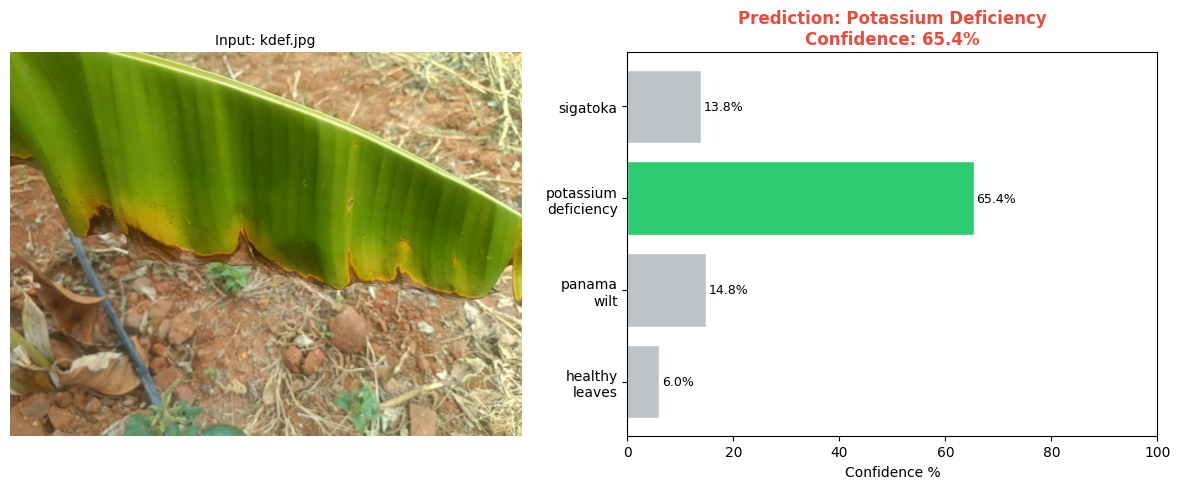


Result: POTASSIUM DEFICIENCY  (65.4% confident)
⚠ Low confidence — image may not be a banana leaf or quality is poor


In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import matplotlib.pyplot as plt

# ── Load best model if not already loaded ─────────────────────────────
import os
if 'best_model' not in dir():
    best_model = keras.models.load_model(Config.FINAL_MODEL_PATH)
    print("Model loaded")

# ── Upload any image from your device ─────────────────────────────────
print("Upload an image (JPG/PNG from Google Images or anywhere)...")
uploaded = files.upload()

for filename, file_bytes in uploaded.items():
    # ── Preprocess exactly as training did ────────────────────────────
    img = Image.open(__import__('io').BytesIO(file_bytes)).convert('RGB')
    img_resized = img.resize(Config.IMAGE_SIZE)
    arr = np.array(img_resized) / 255.0
    arr = np.expand_dims(arr, axis=0)  # shape (1, 256, 256, 3)

    # ── Predict ───────────────────────────────────────────────────────
    preds = best_model.predict(arr, verbose=0)[0]
    pred_idx = np.argmax(preds)
    pred_class = Config.CLASSES[pred_idx]
    confidence = preds[pred_idx] * 100

    # ── Display ───────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img)
    axes[0].set_title(f'Input: {filename}', fontsize=10)
    axes[0].axis('off')

    colors = ['#2ecc71' if i == pred_idx else '#bdc3c7' for i in range(len(Config.CLASSES))]
    bars = axes[1].barh(
        [c.replace('_', '\n') for c in Config.CLASSES],
        preds * 100,
        color=colors,
        edgecolor='white'
    )
    axes[1].set_xlabel('Confidence %')
    axes[1].set_title(
        f'Prediction: {pred_class.replace("_", " ").title()}\nConfidence: {confidence:.1f}%',
        fontweight='bold', fontsize=12,
        color='#2ecc71' if confidence > 80 else '#e74c3c'
    )
    axes[1].set_xlim(0, 100)
    for bar, val in zip(bars, preds * 100):
        axes[1].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f"\nResult: {pred_class.replace('_', ' ').upper()}  ({confidence:.1f}% confident)")
    if confidence < 70:
        print("⚠ Low confidence — image may not be a banana leaf or quality is poor")

In [3]:
from google.colab import drive
drive.mount('/content/gdrive')

import tensorflow as tf
import os

# Step 1 — Load
print("Loading model... (may take 30-60 seconds)")
model = tf.keras.models.load_model(
    '/content/gdrive/MyDrive/Banana_Leaf_Processed_Main/models/final_model.keras'
)
print("✅ Model loaded!")

# Step 2 — Save as .h5 immediately
save_path = '/content/gdrive/MyDrive/Banana_Leaf_Processed_Main/models/final_model.h5'
model.save(save_path)
size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"✅ Saved as .h5 → {save_path}")
print(f"   Size: {size_mb:.1f} MB")

# Step 3 — Download immediately
from google.colab import files
files.download(save_path)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Loading model... (may take 30-60 seconds)


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 83 variables whereas the saved optimizer has 87 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Model loaded!
✅ Saved as .h5 → /content/gdrive/MyDrive/Banana_Leaf_Processed_Main/models/final_model.h5
   Size: 205.5 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>